# Day 2 — From-Scratch Neural Network (NumPy)

A 2-layer MLP for 10-class digit classification, written from scratch with NumPy. Forward pass, ReLU, softmax, cross-entropy loss, and the **backward pass derived by hand** in `README.md` and implemented one-to-one here. Trained with mini-batch SGD.

Architecture: `input (64) → hidden (64, ReLU) → output (10, softmax)`.  Target ≥ 90% test accuracy.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

RNG_SEED = 42
np.random.seed(RNG_SEED)        # used for weight init shortly

## 1. Load and inspect the data

`load_digits` gives us ~1800 hand-written digit images, 8×8 pixels each, with integer pixel values in `[0, 16]`. The first image is shown below — these are *very* low-resolution, which is why training a small from-scratch network can hit 90%+ accuracy without us doing anything fancy.

X_raw shape : (1797, 64)
y_raw shape : (1797,)
pixel range : 0.0 .. 16.0
label range : 0 .. 9


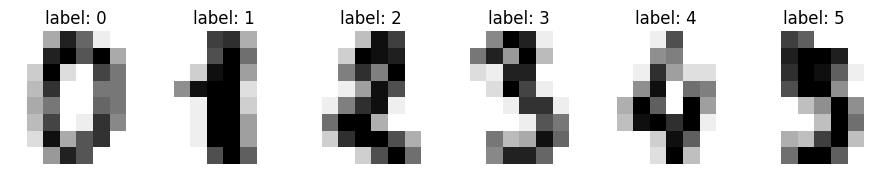

In [2]:
digits = load_digits()
X_raw = digits.data        # shape (1797, 64) — already flattened from 8x8
y_raw = digits.target      # shape (1797,)    — integer labels 0..9

print('X_raw shape :', X_raw.shape)
print('y_raw shape :', y_raw.shape)
print('pixel range :', X_raw.min(), '..', X_raw.max())
print('label range :', y_raw.min(), '..', y_raw.max())

# Plot a few examples so we can SEE what the model has to learn.
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, img, label in zip(axes, digits.images[:6], y_raw[:6]):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Preprocess: normalize + one-hot + split

Three preprocessing steps:

1. **Scale pixels into `[0, 1]`** by dividing by 16. Keeps activations and weights in similar magnitudes — useful when we initialise weights small.
2. **One-hot encode labels** so they match the `(m, 10)` shape that the cross-entropy formula in the README expects: each row has a single `1` at the position of the true class.
3. **Train/test split, 80/20.** Day 1 fitted on all data because we were checking numerics. Day 2 measures generalisation — the model never sees the test set during training.

In [3]:
X = X_raw.astype(np.float64) / 16.0    # now in [0, 1]

# One-hot encode labels: y_raw=3 becomes [0,0,0,1,0,0,0,0,0,0]
n_classes = 10
Y = np.zeros((y_raw.shape[0], n_classes))
Y[np.arange(y_raw.shape[0]), y_raw] = 1

# 80/20 split — stratified so each class is represented proportionally in both splits.
X_train, X_test, Y_train, Y_test, y_train_int, y_test_int = train_test_split(
    X, Y, y_raw, test_size=0.2, random_state=RNG_SEED, stratify=y_raw
)

print('X_train:', X_train.shape, '   Y_train:', Y_train.shape)
print('X_test :', X_test.shape,  '   Y_test :', Y_test.shape)
print()
print('First Y_train row (one-hot label):', Y_train[0], '  integer label:', y_train_int[0])

X_train: (1437, 64)    Y_train: (1437, 10)
X_test : (360, 64)    Y_test : (360, 10)

First Y_train row (one-hot label): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]   integer label: 5


## 3. Parameter initialisation

**He initialisation** (also called *Kaiming* init): for a layer with `fan_in` inputs and ReLU activations, sample weights from `N(0, √(2/fan_in))`. Biases start at zero.

Why not just `randn(...) * 0.01` like in older tutorials? Because:

- **Too small → vanishing activations.** Each layer multiplies the variance by roughly `0.01² · fan_in`. With small enough init, A₁ collapses to ~zero and ReLU outputs are all dead — no gradient flows back.
- **Too large → exploding activations.** Z₁ overshoots into regions where the cross-entropy gradient is tiny in absolute value, and training stalls.
- **`√(2/fan_in)` is the choice that keeps the variance of Z roughly constant across layers**, for ReLU specifically. (The factor of 2 accounts for ReLU killing half the inputs in expectation.)

This is one of those tiny details that's the difference between a network that trains in seconds and one that doesn't train at all.

In [4]:
def init_params(n_in=64, n_hidden=64, n_out=10, rng=None):
    """He initialisation for a 2-layer MLP with ReLU.

    Returns
    -------
    params : dict with keys W1, b1, W2, b2 (shapes shown inline below)
    """
    rng = np.random.default_rng(RNG_SEED) if rng is None else rng
    return {
        'W1': rng.standard_normal((n_in, n_hidden))  * np.sqrt(2.0 / n_in),     # (64, h)
        'b1': np.zeros(n_hidden),                                                # (h,)
        'W2': rng.standard_normal((n_hidden, n_out)) * np.sqrt(2.0 / n_hidden),  # (h, 10)
        'b2': np.zeros(n_out),                                                   # (10,)
    }

params = init_params()
for k, v in params.items():
    print(f'  {k:<3} shape {str(v.shape):<10}  mean={v.mean():+.4f}  std={v.std():.4f}')

  W1  shape (64, 64)    mean=-0.0034  std=0.1763
  b1  shape (64,)       mean=+0.0000  std=0.0000
  W2  shape (64, 10)    mean=+0.0009  std=0.1783
  b2  shape (10,)       mean=+0.0000  std=0.0000


## 4. Forward pass

- **ReLU** is trivially `np.maximum(0, Z)`.
- **Softmax** has one stability trick: subtract the row max before `exp` so the largest exponent is 0. Mathematically a no-op (softmax ignores constant shifts); numerically it stops `exp(big)` from overflowing.
- **Cross-entropy** has a `1e-12` floor inside the `log` to avoid `log(0)` if the model ever predicts probability 0 for the true class.
- The function returns the predictions `A₂` plus a `cache` dict of intermediate values — backprop needs `Z₁, A₁, Z₂, A₂` and we compute them all once here.

In [5]:
def relu(Z):
    return np.maximum(0.0, Z)

def softmax(Z):
    """Row-wise softmax with the subtract-max trick for numerical stability."""
    Z_shift = Z - Z.max(axis=1, keepdims=True)          # shift so max in each row is 0
    exp_Z   = np.exp(Z_shift)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

def cross_entropy_loss(A2, Y, eps=1e-12):
    """Mean cross-entropy across the batch.  A2 and Y are both (m, n_classes)."""
    m = Y.shape[0]
    return -np.sum(Y * np.log(A2 + eps)) / m

def forward(X, params):
    """Compute predictions and cache the intermediates needed for backprop."""
    Z1 = X @ params['W1'] + params['b1']      # (m, h)
    A1 = relu(Z1)                              # (m, h)
    Z2 = A1 @ params['W2'] + params['b2']      # (m, 10)
    A2 = softmax(Z2)                           # (m, 10)
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

# Quick sanity check on the untrained net:
A2_init, _ = forward(X_train, params)
print('A2 shape                            :', A2_init.shape)
print('Each row sums to (should be ~1.0)   :', np.unique(A2_init.sum(axis=1).round(6))[:3], '…')
print('Initial loss (should be ~log(10) ≈ 2.30): {:.4f}'.format(cross_entropy_loss(A2_init, Y_train)))

A2 shape                            : (1437, 10)
Each row sums to (should be ~1.0)   : [1.] …
Initial loss (should be ~log(10) ≈ 2.30): 2.3509


## 5. Backward pass (hand-coded backprop)

One-to-one with the derivation in `README.md`:

    dZ₂ = (A₂ − Y) / m
    dW₂ = A₁ᵀ · dZ₂
    db₂ = column-sum of dZ₂
    dA₁ = dZ₂ · W₂ᵀ
    dZ₁ = dA₁ ⊙ 1[Z₁ > 0]
    dW₁ = Xᵀ · dZ₁
    db₁ = column-sum of dZ₁

Shapes are the easy thing to verify (each `dX` must match its `X`); the hard thing is verifying the *values* are correct. For that we run a **gradient check** below.

In [6]:
def backward(X, Y, params, cache):
    """Analytical gradients for W1, b1, W2, b2 (one-to-one with the README derivation)."""
    m  = X.shape[0]
    A1, Z1, A2 = cache['A1'], cache['Z1'], cache['A2']
    W2 = params['W2']

    dZ2 = (A2 - Y) / m                  # (m, 10)   softmax+CE simplification
    dW2 = A1.T @ dZ2                    # (h, 10)
    db2 = dZ2.sum(axis=0)               # (10,)

    dA1 = dZ2 @ W2.T                    # (m, h)
    dZ1 = dA1 * (Z1 > 0)                # (m, h)    ReLU mask
    dW1 = X.T  @ dZ1                    # (64, h)
    db1 = dZ1.sum(axis=0)               # (h,)

    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

# Quick shape check
A2, cache = forward(X_train, params)
grads = backward(X_train, Y_train, params, cache)
for k in params:
    assert grads[k].shape == params[k].shape, f'{k}: {grads[k].shape} vs {params[k].shape}'
    print(f'  d{k:<3} shape {grads[k].shape} OK')

  dW1  shape (64, 64) OK
  db1  shape (64,) OK
  dW2  shape (64, 10) OK
  db2  shape (10,) OK


### Gradient check

For any single scalar parameter `θ`, the **central-difference numerical gradient** is

$$\left. \frac{\partial L}{\partial \theta} \right|_{\theta_0} \approx \frac{L(\theta_0 + \varepsilon) - L(\theta_0 - \varepsilon)}{2\varepsilon}$$

for small ε (we'll use `1e-5`). It's accurate to `O(ε²)` and slow — every parameter we check requires *two* full forward passes. We can't afford to check all 4,810 parameters, so we sample a few random entries per tensor.

**The relative error formula** we use to compare numerical vs analytical:

$$\text{rel\_err} = \frac{|g_\text{analytical} - g_\text{numerical}|}{\max(|g_\text{analytical}|, |g_\text{numerical}|) + 10^{-12}}$$

Rule of thumb: `< 1e-6` is perfect, `< 1e-4` is fine, `> 1e-2` means the backward pass is buggy. If we got the math right, all checks should be under `1e-7`.

In [7]:
def gradient_check(X, Y, params, grads, n_checks_per_tensor=5, eps=1e-5):
    """Sample a few entries per tensor, compare numerical vs analytical gradient, return the max relative error."""
    rng = np.random.default_rng(0)
    max_err_overall = 0.0
    for key in params:
        flat_size = params[key].size
        idxs = rng.choice(flat_size, size=min(n_checks_per_tensor, flat_size), replace=False)
        max_err = 0.0
        for flat_idx in idxs:
            original = params[key].flat[flat_idx]

            params[key].flat[flat_idx] = original + eps
            A2_plus, _ = forward(X, params)
            L_plus     = cross_entropy_loss(A2_plus, Y)

            params[key].flat[flat_idx] = original - eps
            A2_minus, _ = forward(X, params)
            L_minus     = cross_entropy_loss(A2_minus, Y)

            params[key].flat[flat_idx] = original             # restore

            grad_num      = (L_plus - L_minus) / (2 * eps)
            grad_analytic = grads[key].flat[flat_idx]
            rel_err       = abs(grad_analytic - grad_num) / (max(abs(grad_analytic), abs(grad_num)) + 1e-12)
            max_err       = max(max_err, rel_err)
        print(f'  {key:<3} max relative error across {n_checks_per_tensor} samples: {max_err:.2e}')
        max_err_overall = max(max_err_overall, max_err)
    return max_err_overall

max_err = gradient_check(X_train, Y_train, params, grads)
assert max_err < 1e-5, f'Gradient check failed: max error {max_err:.2e}'
print(f'\nbackward pass verified — max relative error across all checks: {max_err:.2e}')

  W1  max relative error across 5 samples: 1.11e-07
  b1  max relative error across 5 samples: 1.38e-07
  W2  max relative error across 5 samples: 8.93e-07
  b2  max relative error across 5 samples: 2.31e-09

backward pass verified — max relative error across all checks: 8.93e-07


## 6. Training: mini-batch SGD

At each step we use a *batch* of training examples — not all of them (full-batch GD: slow, deterministic) and not just one (pure SGD: noisy and bouncy). Batch size of 32 is the standard sweet spot.

Per epoch we:

1. **Shuffle** the training indices. Without this, the model sees the same batch sequence every epoch and the loss curve develops weird oscillations from correlated updates.
2. Walk through mini-batches, running `forward → backward → update` for each.
3. Record the **mean loss across the epoch** (smoother than the last batch's loss) and the **test-set accuracy** (this is what the 90% target is measured on).

In [8]:
def predict_classes(X, params):
    A2, _ = forward(X, params)
    return A2.argmax(axis=1)

def accuracy(X, y_int, params):
    return (predict_classes(X, params) == y_int).mean()

def train(X_train, Y_train, y_train_int, X_test, y_test_int,
          alpha=0.1, n_epochs=30, batch_size=32, seed=RNG_SEED, verbose=True):
    rng = np.random.default_rng(seed)
    params = init_params(rng=rng)
    m = X_train.shape[0]

    train_loss_history = []
    test_acc_history   = []

    for epoch in range(n_epochs):
        idxs = rng.permutation(m)                  # shuffle each epoch
        epoch_losses = []
        for start in range(0, m, batch_size):
            batch = idxs[start:start + batch_size]
            X_b = X_train[batch]
            Y_b = Y_train[batch]
            A2, cache = forward(X_b, params)
            epoch_losses.append(cross_entropy_loss(A2, Y_b))
            grads = backward(X_b, Y_b, params, cache)
            for k in params:
                params[k] -= alpha * grads[k]

        train_loss_history.append(np.mean(epoch_losses))
        test_acc_history.append(accuracy(X_test, y_test_int, params))

        if verbose and (epoch < 3 or (epoch + 1) % 5 == 0):
            print(f'  epoch {epoch+1:>3}/{n_epochs}   '
                  f'train loss = {train_loss_history[-1]:.4f}   '
                  f'test acc = {test_acc_history[-1]:.4f}')
    return params, train_loss_history, test_acc_history

trained_params, loss_hist, acc_hist = train(
    X_train, Y_train, y_train_int, X_test, y_test_int,
    alpha=0.1, n_epochs=30, batch_size=32,
)
print(f'\nFinal train loss : {loss_hist[-1]:.4f}')
print(f'Final test acc   : {acc_hist[-1]*100:.2f}%')

  epoch   1/30   train loss = 1.7122   test acc = 0.7778
  epoch   2/30   train loss = 0.8772   test acc = 0.8417
  epoch   3/30   train loss = 0.5428   test acc = 0.9028
  epoch   5/30   train loss = 0.3175   test acc = 0.9250
  epoch  10/30   train loss = 0.1743   test acc = 0.9389


  epoch  15/30   train loss = 0.1273   test acc = 0.9472


  epoch  20/30   train loss = 0.1017   test acc = 0.9583


  epoch  25/30   train loss = 0.0847   test acc = 0.9611
  epoch  30/30   train loss = 0.0710   test acc = 0.9583

Final train loss : 0.0710
Final test acc   : 95.83%


## 7. Diagnostics

Three things worth looking at:

1. **Loss curve** — sanity check that training was stable (no spikes, no divergence).
2. **Test accuracy curve** — does the model overfit late in training? (If yes, train and test diverge.)
3. **Confusion matrix + misclassified digits** — for the ones the model got wrong, *what* did it confuse them with? Often the answer is intuitive (4s look like 9s, 3s look like 8s) and tells you something about the dataset.

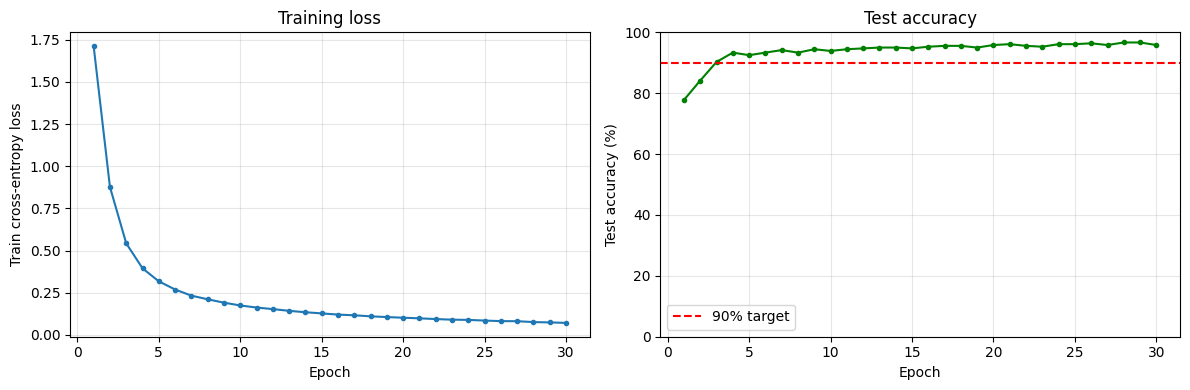

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(range(1, len(loss_hist)+1), loss_hist, marker='o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train cross-entropy loss')
axes[0].set_title('Training loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, len(acc_hist)+1), [a*100 for a in acc_hist], marker='o', markersize=3, color='green')
axes[1].axhline(90, color='red', linestyle='--', label='90% target')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test accuracy (%)')
axes[1].set_title('Test accuracy')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day2_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()

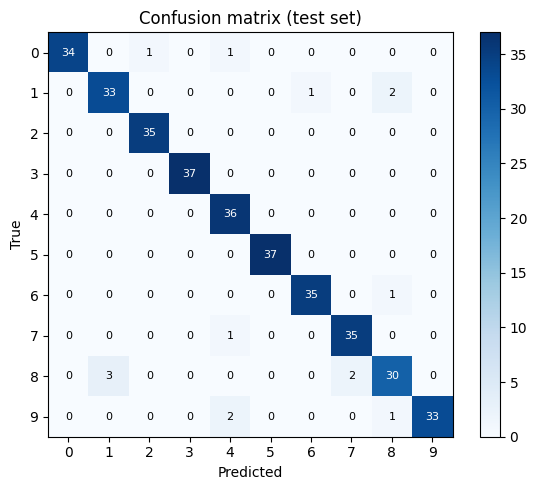

Misclassified 15 of 360 test examples


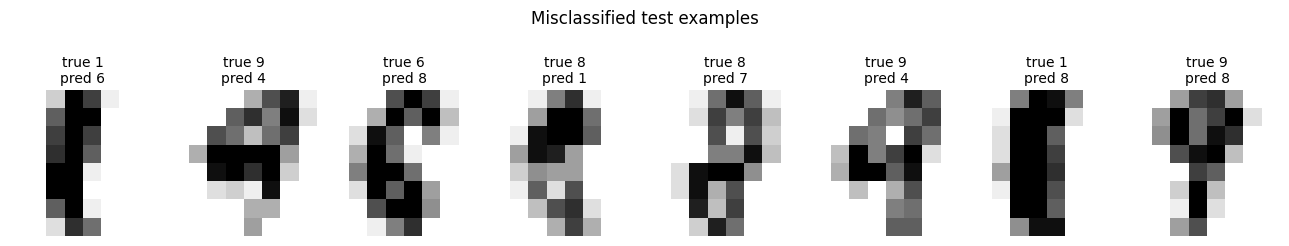

In [10]:
# Confusion matrix on the test set
y_pred = predict_classes(X_test, trained_params)
conf = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test_int, y_pred):
    conf[true, pred] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix (test set)')
for i in range(10):
    for j in range(10):
        color = 'white' if conf[i, j] > conf.max() * 0.5 else 'black'
        ax.text(j, i, str(conf[i, j]), ha='center', va='center', color=color, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('day2_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# Show a few misclassified digits with predicted vs true labels
miscls = np.where(y_pred != y_test_int)[0]
print(f'Misclassified {len(miscls)} of {len(y_test_int)} test examples')
if len(miscls) > 0:
    n_show = min(8, len(miscls))
    fig2, axs = plt.subplots(1, n_show, figsize=(13, 2.5))
    for ax, idx in zip(axs, miscls[:n_show]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap='gray_r')
        ax.set_title(f'true {y_test_int[idx]}\npred {y_pred[idx]}', fontsize=10)
        ax.axis('off')
    fig2.suptitle('Misclassified test examples', y=1.05)
    fig2.tight_layout()
    plt.savefig('day2_misclassified.png', dpi=120, bbox_inches='tight')
    plt.show()